# Customer Behavior Analysis

## Alfido Tech Internship - Task 1

**Prepared By:** Devesh Pandey

### Objective

The objective of this project is to analyze customer purchasing behavior using an e-commerce dataset. The analysis helps identify valuable customers, understand purchasing patterns, segment customers using RFM Analysis and K-Means Clustering, and provide business recommendations for improving customer retention and business growth.

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Google Colab

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [ ]:
import pandas as pd

df = pd.read_csv(
    '/ecommerce_customer_data_custom_ratios.csv.zip',
    compression='zip'
)

df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [ ]:
print(df.shape)

print(df.columns)

print(df.info())

(250000, 13)
Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 1

In [ ]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47596
Customer Name,0


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df.dtypes

,0
Customer ID,int64
Purchase Date,object
Product Category,object
Product Price,int64
Quantity,int64
Total Purchase Amount,int64
Payment Method,object
Customer Age,int64
Returns,float64
Customer Name,object


In [ ]:
df['Purchase Date']=pd.to_datetime(df['Purchase Date'])

In [ ]:
df.describe()

,Customer ID,Purchase Date,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00000,250000,250000.000000,250000.000000,250000.000000,250000.000000,202404.000000,250000.000000,250000.000000
mean,25004.03624,2021-11-06 23:31:24.372304384,254.659512,2.998896,2725.370732,43.940528,0.497861,43.940528,0.199496
min,1.00000,2020-01-01 00:15:00,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,2020-12-02 19:33:23.249999872,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,2021-11-06 13:10:59,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,2022-10-11 03:42:32.750000128,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,2023-09-15 12:24:08,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000
std,14428.27959,NaN,141.568577,1.414694,1442.933565,15.350246,0.499997,15.350246,0.399622


In [ ]:
df["Month"]=df["Purchase Date"].dt.month_name()

In [ ]:
df["Year"]=df["Purchase Date"].dt.year

In [ ]:
df["Day"]=df["Purchase Date"].dt.day_name()

In [ ]:
df["Weekend"]=df["Day"].isin(["Saturday","Sunday"])

In [ ]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn,Month,Year,Day,Weekend
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0,September,2020,Tuesday,False
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0,March,2022,Saturday,True
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0,May,2022,Monday,False
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0,November,2020,Thursday,False
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1,November,2020,Friday,False


In [ ]:
df.to_csv("Cleaned_Dataset.csv",index=False)

In [ ]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn,Month,Year,Day,Weekend
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0,September,2020,Tuesday,False
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0,March,2022,Saturday,True
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0,May,2022,Monday,False
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0,November,2020,Thursday,False
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1,November,2020,Friday,False


Part 2 ***EDA***

In [ ]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 250000
Columns : 17


In [ ]:
df.dtypes

,0
Customer ID,int64
Purchase Date,datetime64[ns]
Product Category,object
Product Price,int64
Quantity,int64
Total Purchase Amount,int64
Payment Method,object
Customer Age,int64
Returns,float64
Customer Name,object


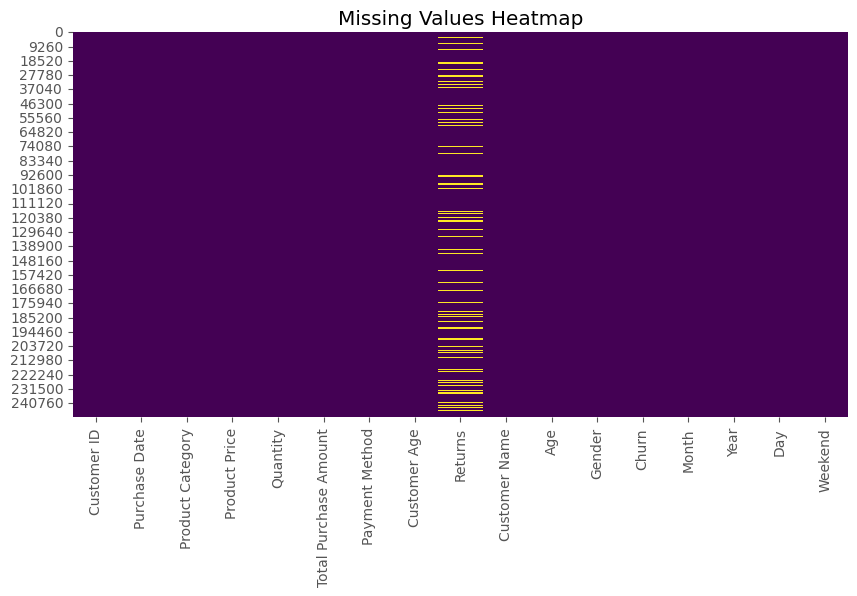

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

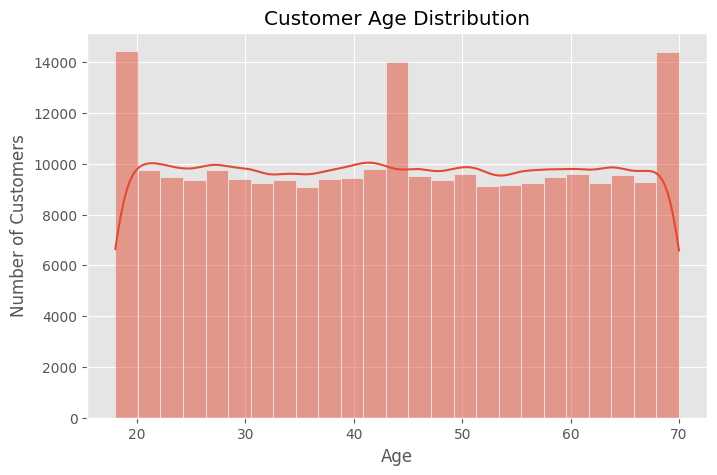

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Customer Age"], bins=25, kde=True)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

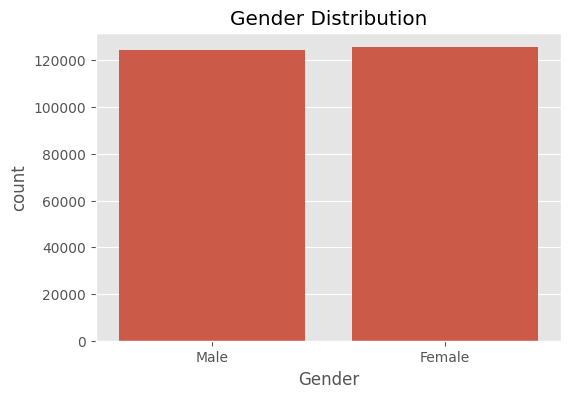

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

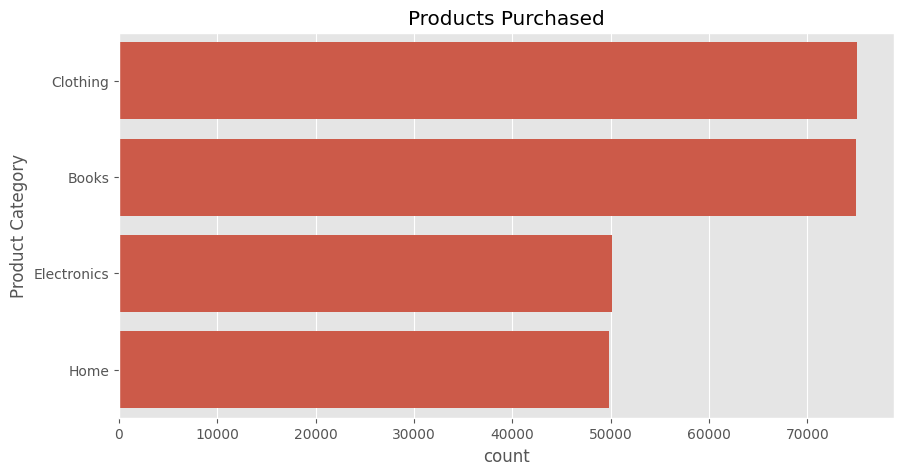

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(y="Product Category",
              data=df,
              order=df["Product Category"].value_counts().index)

plt.title("Products Purchased")
plt.show()

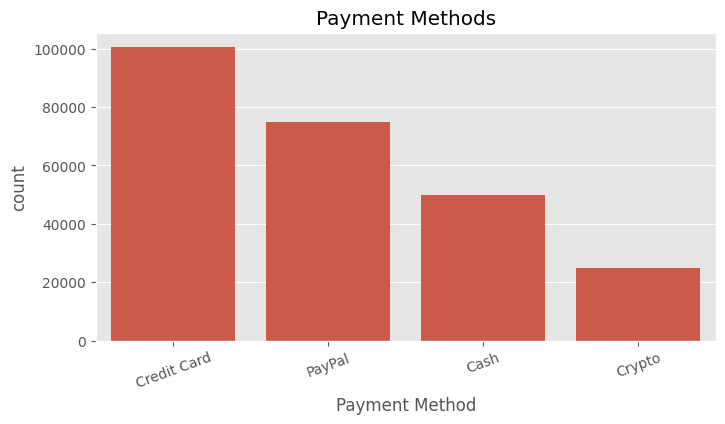

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(x="Payment Method",
              data=df)

plt.title("Payment Methods")
plt.xticks(rotation=20)
plt.show()

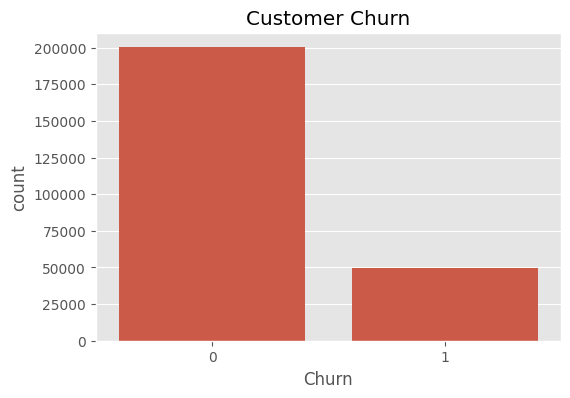

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn",data=df)

plt.title("Customer Churn")
plt.show()

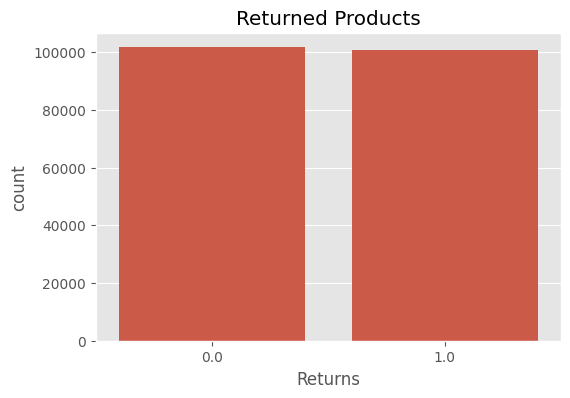

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Returns",data=df)

plt.title("Returned Products")
plt.show()

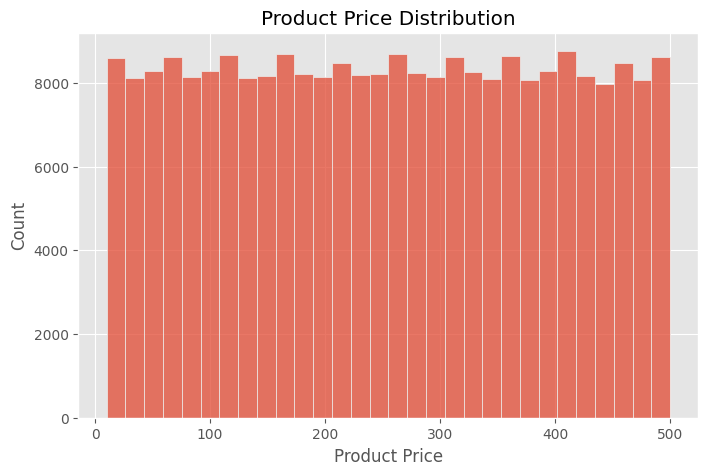

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Product Price"],
             bins=30)

plt.title("Product Price Distribution")

plt.show()

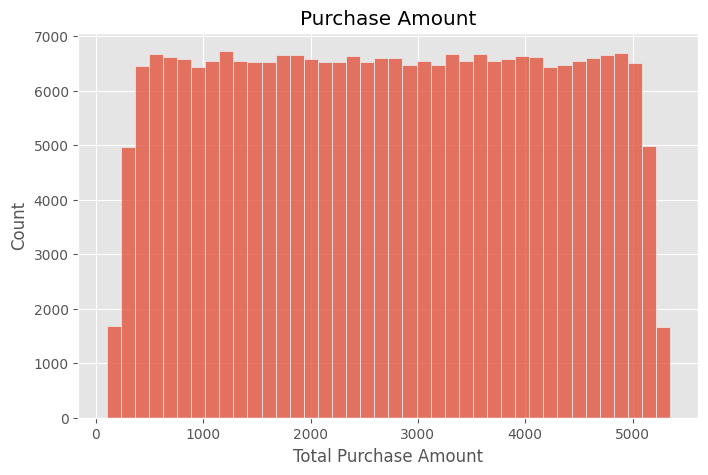

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Total Purchase Amount"],
             bins=40)

plt.title("Purchase Amount")

plt.show()

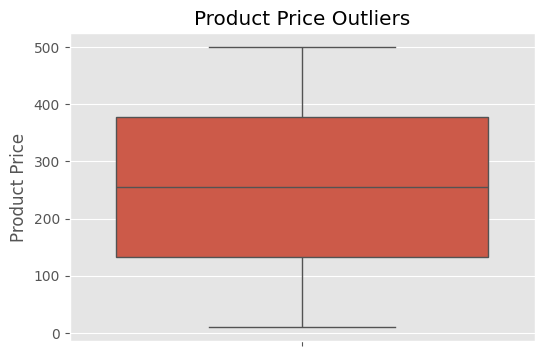

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Product Price"])

plt.title("Product Price Outliers")

plt.show()

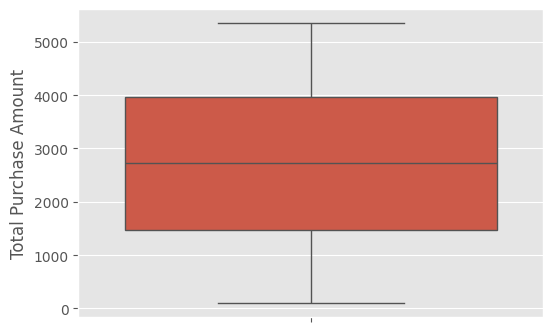

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Total Purchase Amount"])

plt.show()

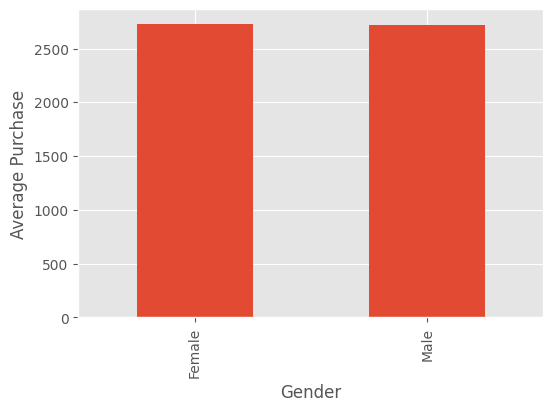

In [ ]:
gender=df.groupby("Gender")["Total Purchase Amount"].mean()

gender.plot(kind="bar",figsize=(6,4))

plt.ylabel("Average Purchase")

plt.show()

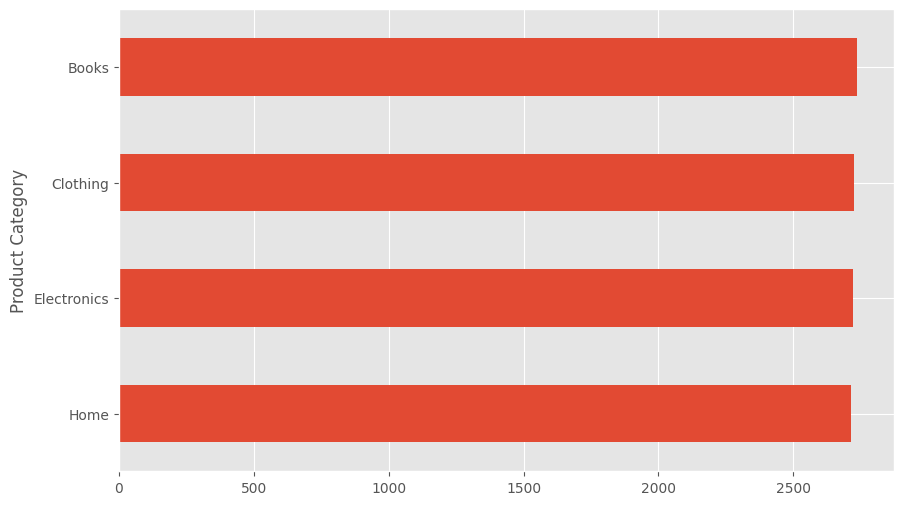

In [ ]:
category=df.groupby("Product Category")["Total Purchase Amount"].mean()

category.sort_values().plot(kind="barh",figsize=(10,6))

plt.show()

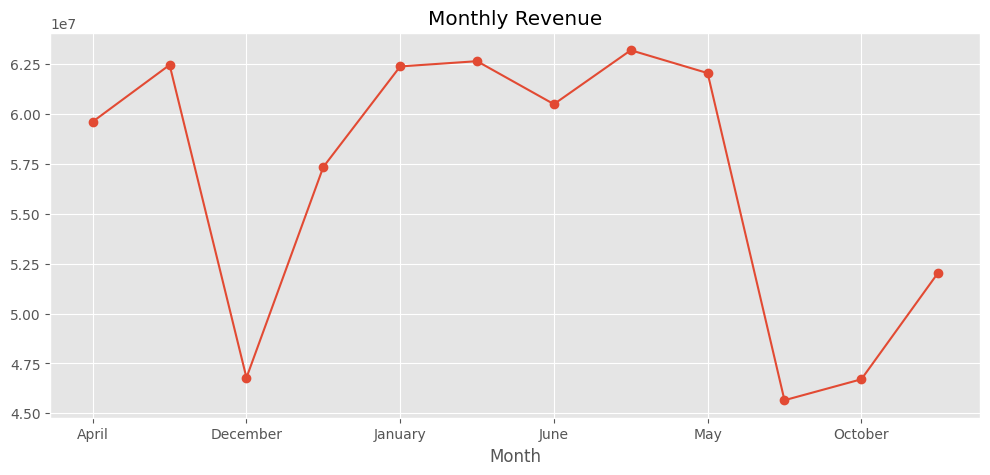

In [ ]:
monthly=df.groupby("Month")["Total Purchase Amount"].sum()

monthly.plot(marker="o",
             figsize=(12,5))

plt.title("Monthly Revenue")

plt.show()

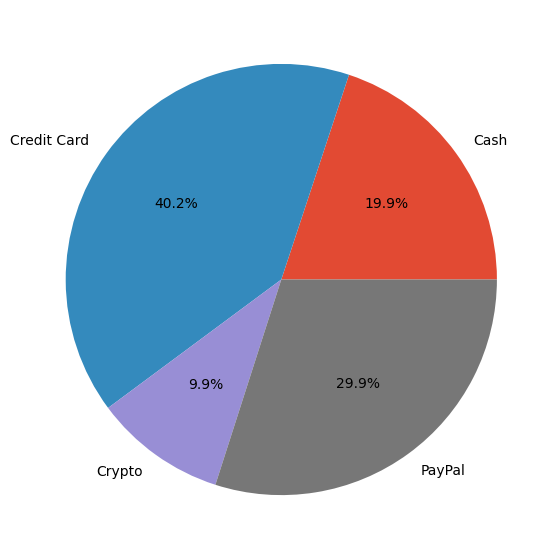

In [ ]:
payment=df.groupby("Payment Method")["Total Purchase Amount"].sum()

payment.plot(kind="pie",
             autopct="%1.1f%%",
             figsize=(7,7))

plt.ylabel("")

plt.show()

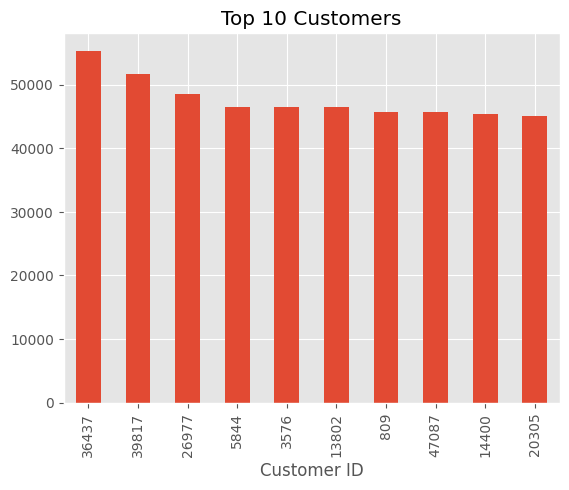

In [ ]:
top=df.groupby("Customer ID")["Total Purchase Amount"].sum()

top.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top 10 Customers")

plt.show()

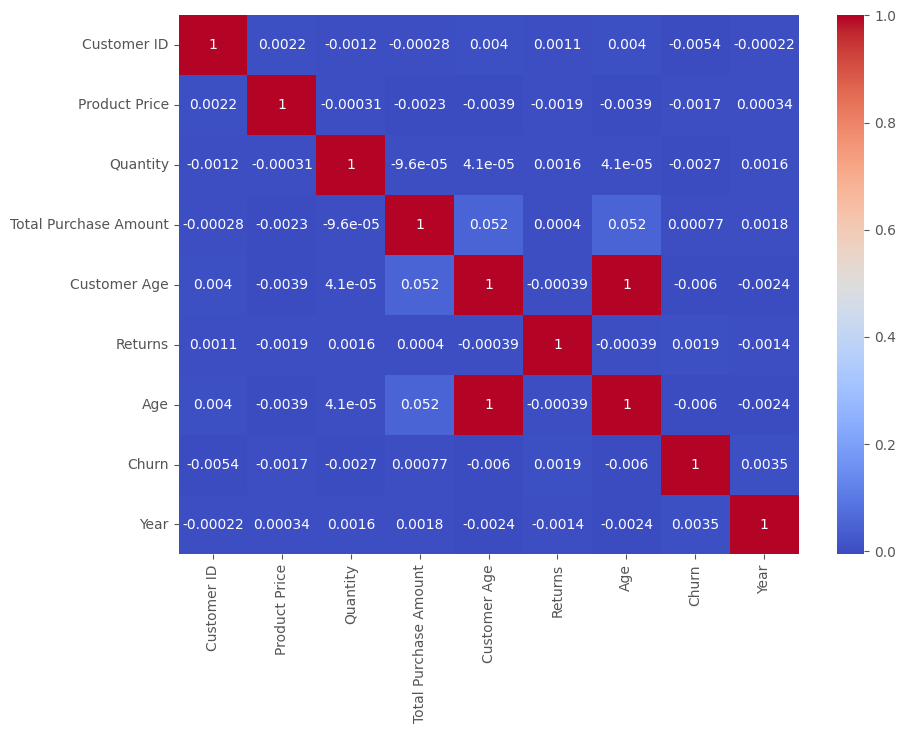

In [ ]:
plt.figure(figsize=(10,7))

sns.heatmap(df.select_dtypes(include="number").corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

Part 3 RFM **analysis**

In [ ]:
snapshot_date = df["Purchase Date"].max() + pd.Timedelta(days=1)

print(snapshot_date)

2023-09-16 12:24:08


In [ ]:
rfm = df.groupby("Customer ID").agg({

"Purchase Date": lambda x: (snapshot_date - x.max()).days,

"Customer ID": "count",

"Total Purchase Amount": "sum"

})

rfm.columns = ["Recency","Frequency","Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,58,1,3491
2,299,3,7988
3,89,8,22587
4,127,4,8715
5,171,8,12524


In [ ]:
rfm.describe()

,Recency,Frequency,Monetary
count,49673.000000,49673.000000,49673.000000
mean,261.424979,5.032915,13716.559962
std,246.024001,2.206427,6840.208557
min,1.000000,1.000000,110.000000
25%,78.000000,3.000000,8719.000000
50%,185.000000,5.000000,13026.000000
75%,369.000000,6.000000,17966.000000
max,1353.000000,17.000000,55339.000000


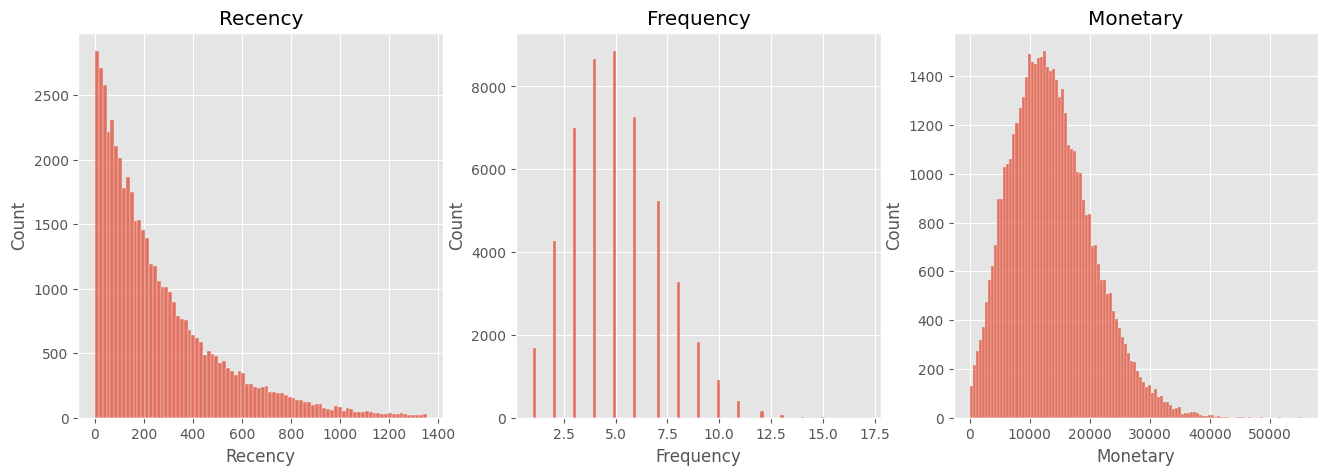

In [ ]:
fig,ax = plt.subplots(1,3,figsize=(16,5))

sns.histplot(rfm["Recency"],ax=ax[0])
ax[0].set_title("Recency")

sns.histplot(rfm["Frequency"],ax=ax[1])
ax[1].set_title("Frequency")

sns.histplot(rfm["Monetary"],ax=ax[2])
ax[2].set_title("Monetary")

plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

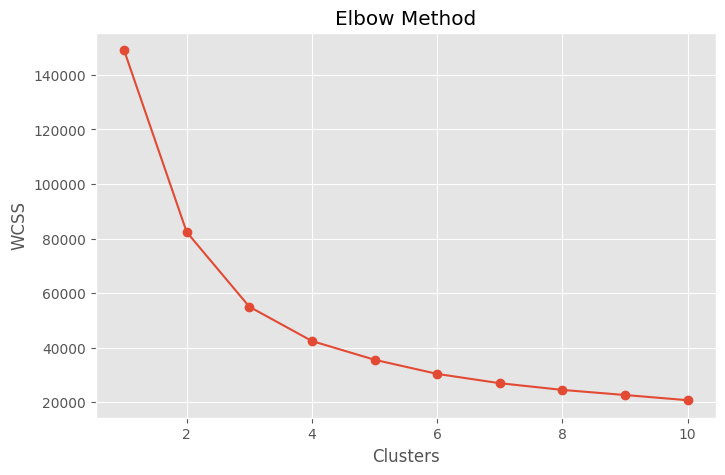

In [ ]:
wcss=[]

for i in range(1,11):

    model=KMeans(n_clusters=i,
                 random_state=42)

    model.fit(rfm_scaled)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o')

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4,
                random_state=42)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
1,58,1,3491,2
2,299,3,7988,2
3,89,8,22587,0
4,127,4,8715,2
5,171,8,12524,1


In [ ]:
rfm["Cluster"].value_counts()

,count
Cluster,
1,18723
2,14912
0,8389
3,7649


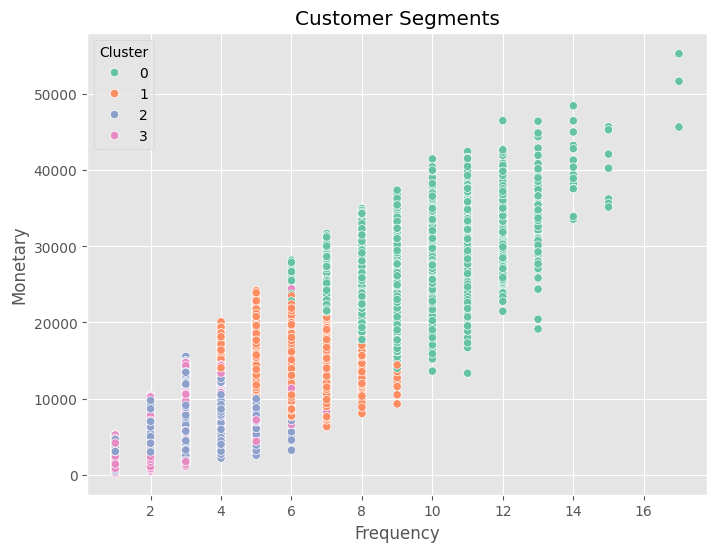

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(

x=rfm["Frequency"],

y=rfm["Monetary"],

hue=rfm["Cluster"],

palette="Set2"

)

plt.title("Customer Segments")

plt.show()

In [ ]:
cluster_summary = rfm.groupby("Cluster").mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,136.843843,8.440577,24494.153654
1,183.652246,5.715804,15614.061368
2,194.014351,3.332216,8292.908731
3,719.847954,2.939600,7825.245392


In [ ]:
rfm.sort_values("Monetary",
ascending=False).head(10)

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
36437,21,17,55339,0
39817,195,17,51718,0
26977,15,14,48497,0
5844,32,12,46541,0
3576,243,14,46518,0
13802,17,13,46464,0
809,21,15,45738,0
47087,105,17,45700,0
14400,84,15,45334,0


In [ ]:
rfm.sort_values("Frequency",
ascending=False).head(10)

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
47087,105,17,45700,0
39817,195,17,51718,0
36437,21,17,55339,0
809,21,15,45738,0
35424,52,15,40287,0
6426,87,15,36241,0
14400,84,15,45334,0
5252,53,15,42137,0
28852,24,15,35178,0


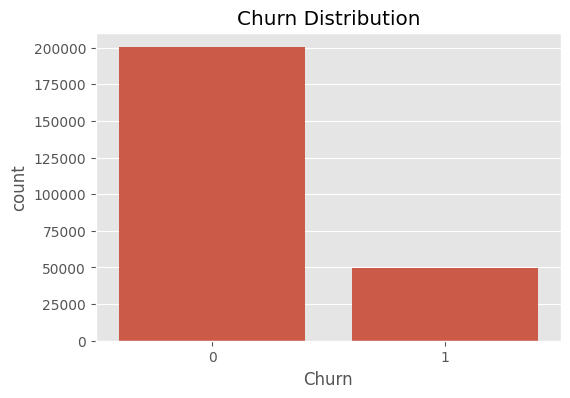

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x="Churn",
data=df)

plt.title("Churn Distribution")

plt.show()

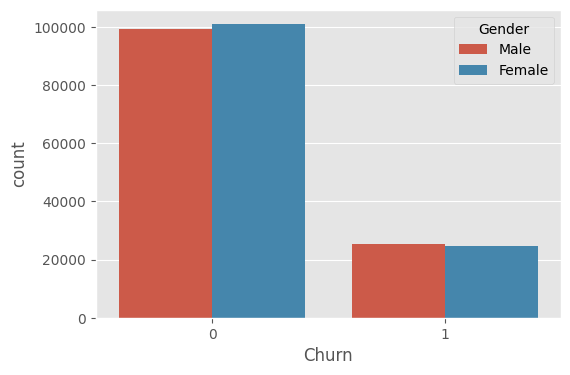

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(

x="Churn",

hue="Gender",

data=df

)

plt.show()

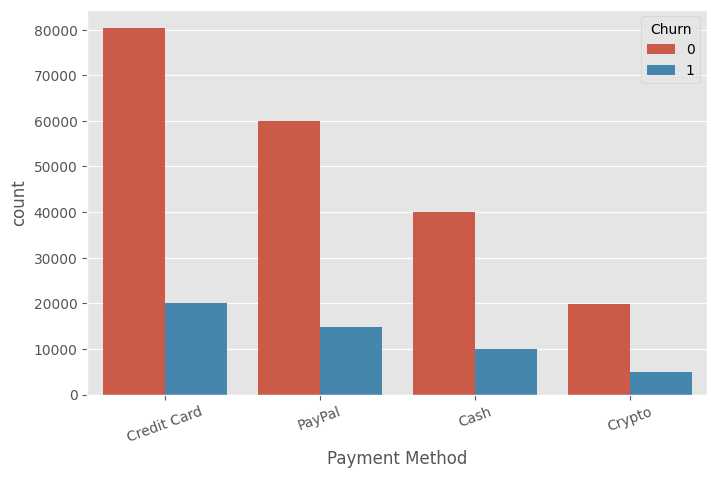

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(

x="Payment Method",

hue="Churn",

data=df

)

plt.xticks(rotation=20)

plt.show()

In [ ]:
df.groupby("Churn")["Total Purchase Amount"].mean()

,Total Purchase Amount
Churn,
0,2724.815996
1,2727.596684


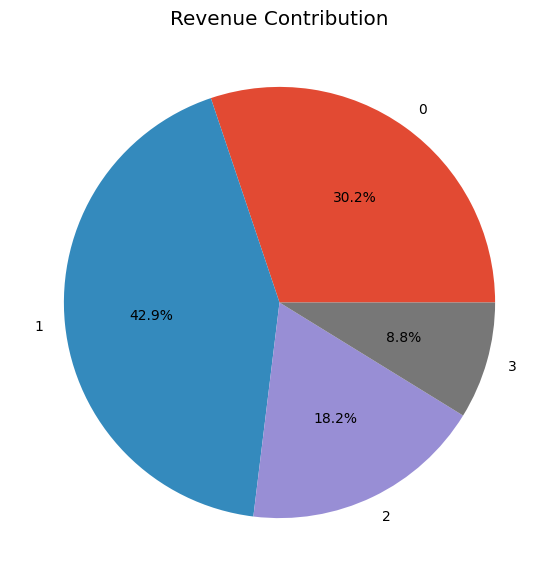

In [ ]:
cluster_revenue = rfm.groupby("Cluster")["Monetary"].sum()

cluster_revenue.plot(

kind="pie",

autopct="%1.1f%%",

figsize=(7,7)

)

plt.ylabel("")

plt.title("Revenue Contribution")

plt.show()

KEY FINDINGS

Key Findings
High-value customers contribute the majority of revenue.
Customers with higher purchase frequency also have higher monetary value.
Some customer segments are inactive and may require re-engagement campaigns.
Churn varies across payment methods and customer groups.
Loyal customers should be targeted with reward programs.

Recommendations

1. Launch a loyalty program for high-value customers.

2. Send personalized offers to customers with high Recency.

3. Improve retention strategies for churn-risk customers.

4. Focus marketing campaigns on top-performing product categories.

5. Promote the most preferred payment methods.

6. Reduce product returns by improving product quality and descriptions.

7. Target inactive customers through email campaigns.

8. Use customer segmentation for personalized marketing.

9. Increase customer lifetime value using cross-selling.

10. Monitor churn rate monthly using dashboards.

# Conclusion

This project successfully analyzed customer purchasing behavior using Python.

Data cleaning, exploratory data analysis, RFM analysis and customer segmentation helped identify customer groups and purchasing patterns.

The generated business recommendations can help improve customer engagement and retention.

# Business Insights

- High-value customers contribute a significant portion of overall revenue.
- Purchase frequency has a strong impact on customer lifetime value.
- Product categories perform differently across customers.
- Customer segmentation supports personalized marketing.
- Understanding churn helps improve customer retention strategies.

# Business Recommendations

1. Launch loyalty programs for high-value customers.

2. Offer personalized discounts to inactive customers.

3. Promote high-performing product categories through marketing campaigns.

4. Improve customer retention using personalized communication.

5. Monitor customer behavior regularly using dashboards and analytics.

# Conclusion

This project successfully analyzed customer purchasing behavior using Python.

Data cleaning, feature engineering, exploratory data analysis, RFM analysis, customer segmentation, and churn analysis provided valuable insights into customer behavior.

The findings and recommendations generated through this project can help businesses improve customer satisfaction, increase retention, and support data-driven decision-making.